<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 5</b></center>
<pre>    

# SVR

# Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Read World bank CSV

In [2]:
df = pd.read_csv('WorldBank.csv')
display(df.head())

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,...,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,...,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [3]:
data = df[df['Indicator Name'] == 'Population ages 15-64 (% of total population)']
data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [4]:
X = np.arange(1960,2020).reshape(-1,1)
y = data.values[0][4:-1].reshape(-1,1)
X

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019]])

In [5]:
y


array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

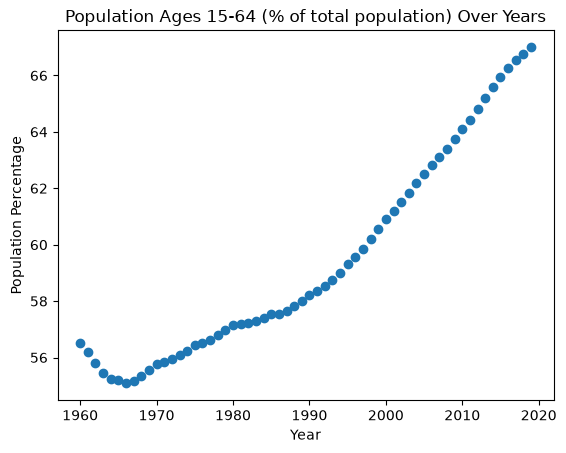

In [6]:
plt.scatter(X,y)
plt.title('Population Ages 15-64 (% of total population) Over Years')
plt.xlabel('Year')
plt.ylabel('Population Percentage')
plt.show()

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [7]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()

In [8]:
X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y)
X_scaled

array([[-1.7034199 ],
       [-1.64567685],
       [-1.5879338 ],
       [-1.53019075],
       [-1.47244771],
       [-1.41470466],
       [-1.35696161],
       [-1.29921857],
       [-1.24147552],
       [-1.18373247],
       [-1.12598942],
       [-1.06824638],
       [-1.01050333],
       [-0.95276028],
       [-0.89501723],
       [-0.83727419],
       [-0.77953114],
       [-0.72178809],
       [-0.66404504],
       [-0.606302  ],
       [-0.54855895],
       [-0.4908159 ],
       [-0.43307286],
       [-0.37532981],
       [-0.31758676],
       [-0.25984371],
       [-0.20210067],
       [-0.14435762],
       [-0.08661457],
       [-0.02887152],
       [ 0.02887152],
       [ 0.08661457],
       [ 0.14435762],
       [ 0.20210067],
       [ 0.25984371],
       [ 0.31758676],
       [ 0.37532981],
       [ 0.43307286],
       [ 0.4908159 ],
       [ 0.54855895],
       [ 0.606302  ],
       [ 0.66404504],
       [ 0.72178809],
       [ 0.77953114],
       [ 0.83727419],
       [ 0

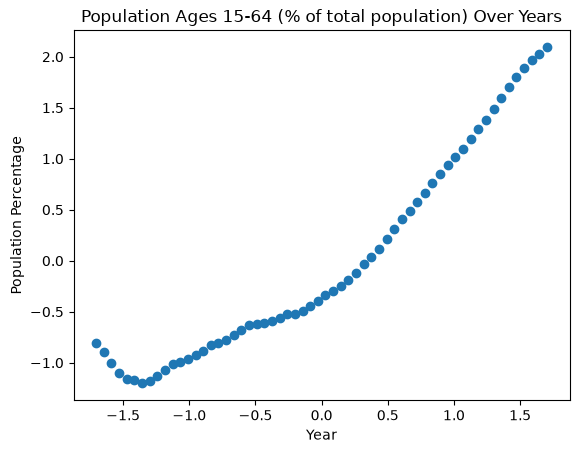

In [9]:
plt.scatter(X_scaled,y_scaled)
plt.title('Population Ages 15-64 (% of total population) Over Years')
plt.xlabel('Year')
plt.ylabel('Population Percentage')
plt.show()

# Splitting the dataset into the Training set and Test set

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled,
                test_size=0.2,random_state=42)

# Fitting SVR on 3 Different Kernel on dataset

In [11]:
from sklearn.svm import SVR

model_linear = SVR(kernel='linear')
model_poly = SVR(kernel='poly', degree=3)
model_rbf = SVR(kernel='rbf')

In [ ]:
model_linear.fit(X_train, y_train.flatten())

In [ ]:
model_poly.fit(X_train, y_train.flatten())

In [ ]:
model_rbf.fit(X_train, y_train.flatten())

In [15]:
print('Linear Kernel R^2 score:', model_linear.score(X_test, y_test.flatten()))

Linear Kernel R^2 score: 0.890692720127772


In [16]:
print('Polynomial Kernel R^2 score:', model_poly.score(X_test, y_test.flatten()))

Polynomial Kernel R^2 score: 0.5878035720918651


In [17]:
print('RBF Kernel R^2 score:', model_rbf.score(X_test, y_test.flatten()))

RBF Kernel R^2 score: 0.9963995902170167


# Predict the x_test using 3 Kernel

In [18]:
y_pred_linear = model_linear.predict(X_test)
y_pred_poly = model_poly.predict(X_test)
y_pred_rbf = model_rbf.predict(X_test)

y_test_original = sc_y.inverse_transform(y_test)
y_pred_linear_original = sc_y.inverse_transform(y_pred_linear.reshape(-1, 1))
y_pred_poly_original = sc_y.inverse_transform(y_pred_poly.reshape(-1, 1))
y_pred_rbf_original = sc_y.inverse_transform(y_pred_rbf.reshape(-1, 1))


In [19]:
display(y_pred_linear)
display(y_pred_linear_original)

array([-1.66205509, -1.39071584,  0.29158747,  0.7799981 , -0.95657305,
        1.26840874,  0.12878392,  0.94280165, -1.0108409 ,  1.43121229,
        0.83426595,  1.05133735])

array([[53.4198773 ],
       [54.40117649],
       [60.48523142],
       [62.25156995],
       [55.97125518],
       [64.01790848],
       [59.89645191],
       [62.84034946],
       [55.77499534],
       [64.60668799],
       [62.44782979],
       [63.23286913]])

In [20]:
y_pred_poly_original

array([[49.69149777],
       [53.60840132],
       [58.95919606],
       [60.19119237],
       [57.2566177 ],
       [64.11381077],
       [58.87642005],
       [61.12262338],
       [56.94685505],
       [66.28929284],
       [60.46559439],
       [61.9382394 ]])

In [21]:
y_pred_rbf_original

array([[56.1641958 ],
       [55.53620333],
       [59.68493746],
       [62.52414274],
       [55.86771897],
       [65.7088615 ],
       [59.03584603],
       [63.68203472],
       [55.75129704],
       [66.29866225],
       [62.90752872],
       [64.43551502]])

# Visualising the  results

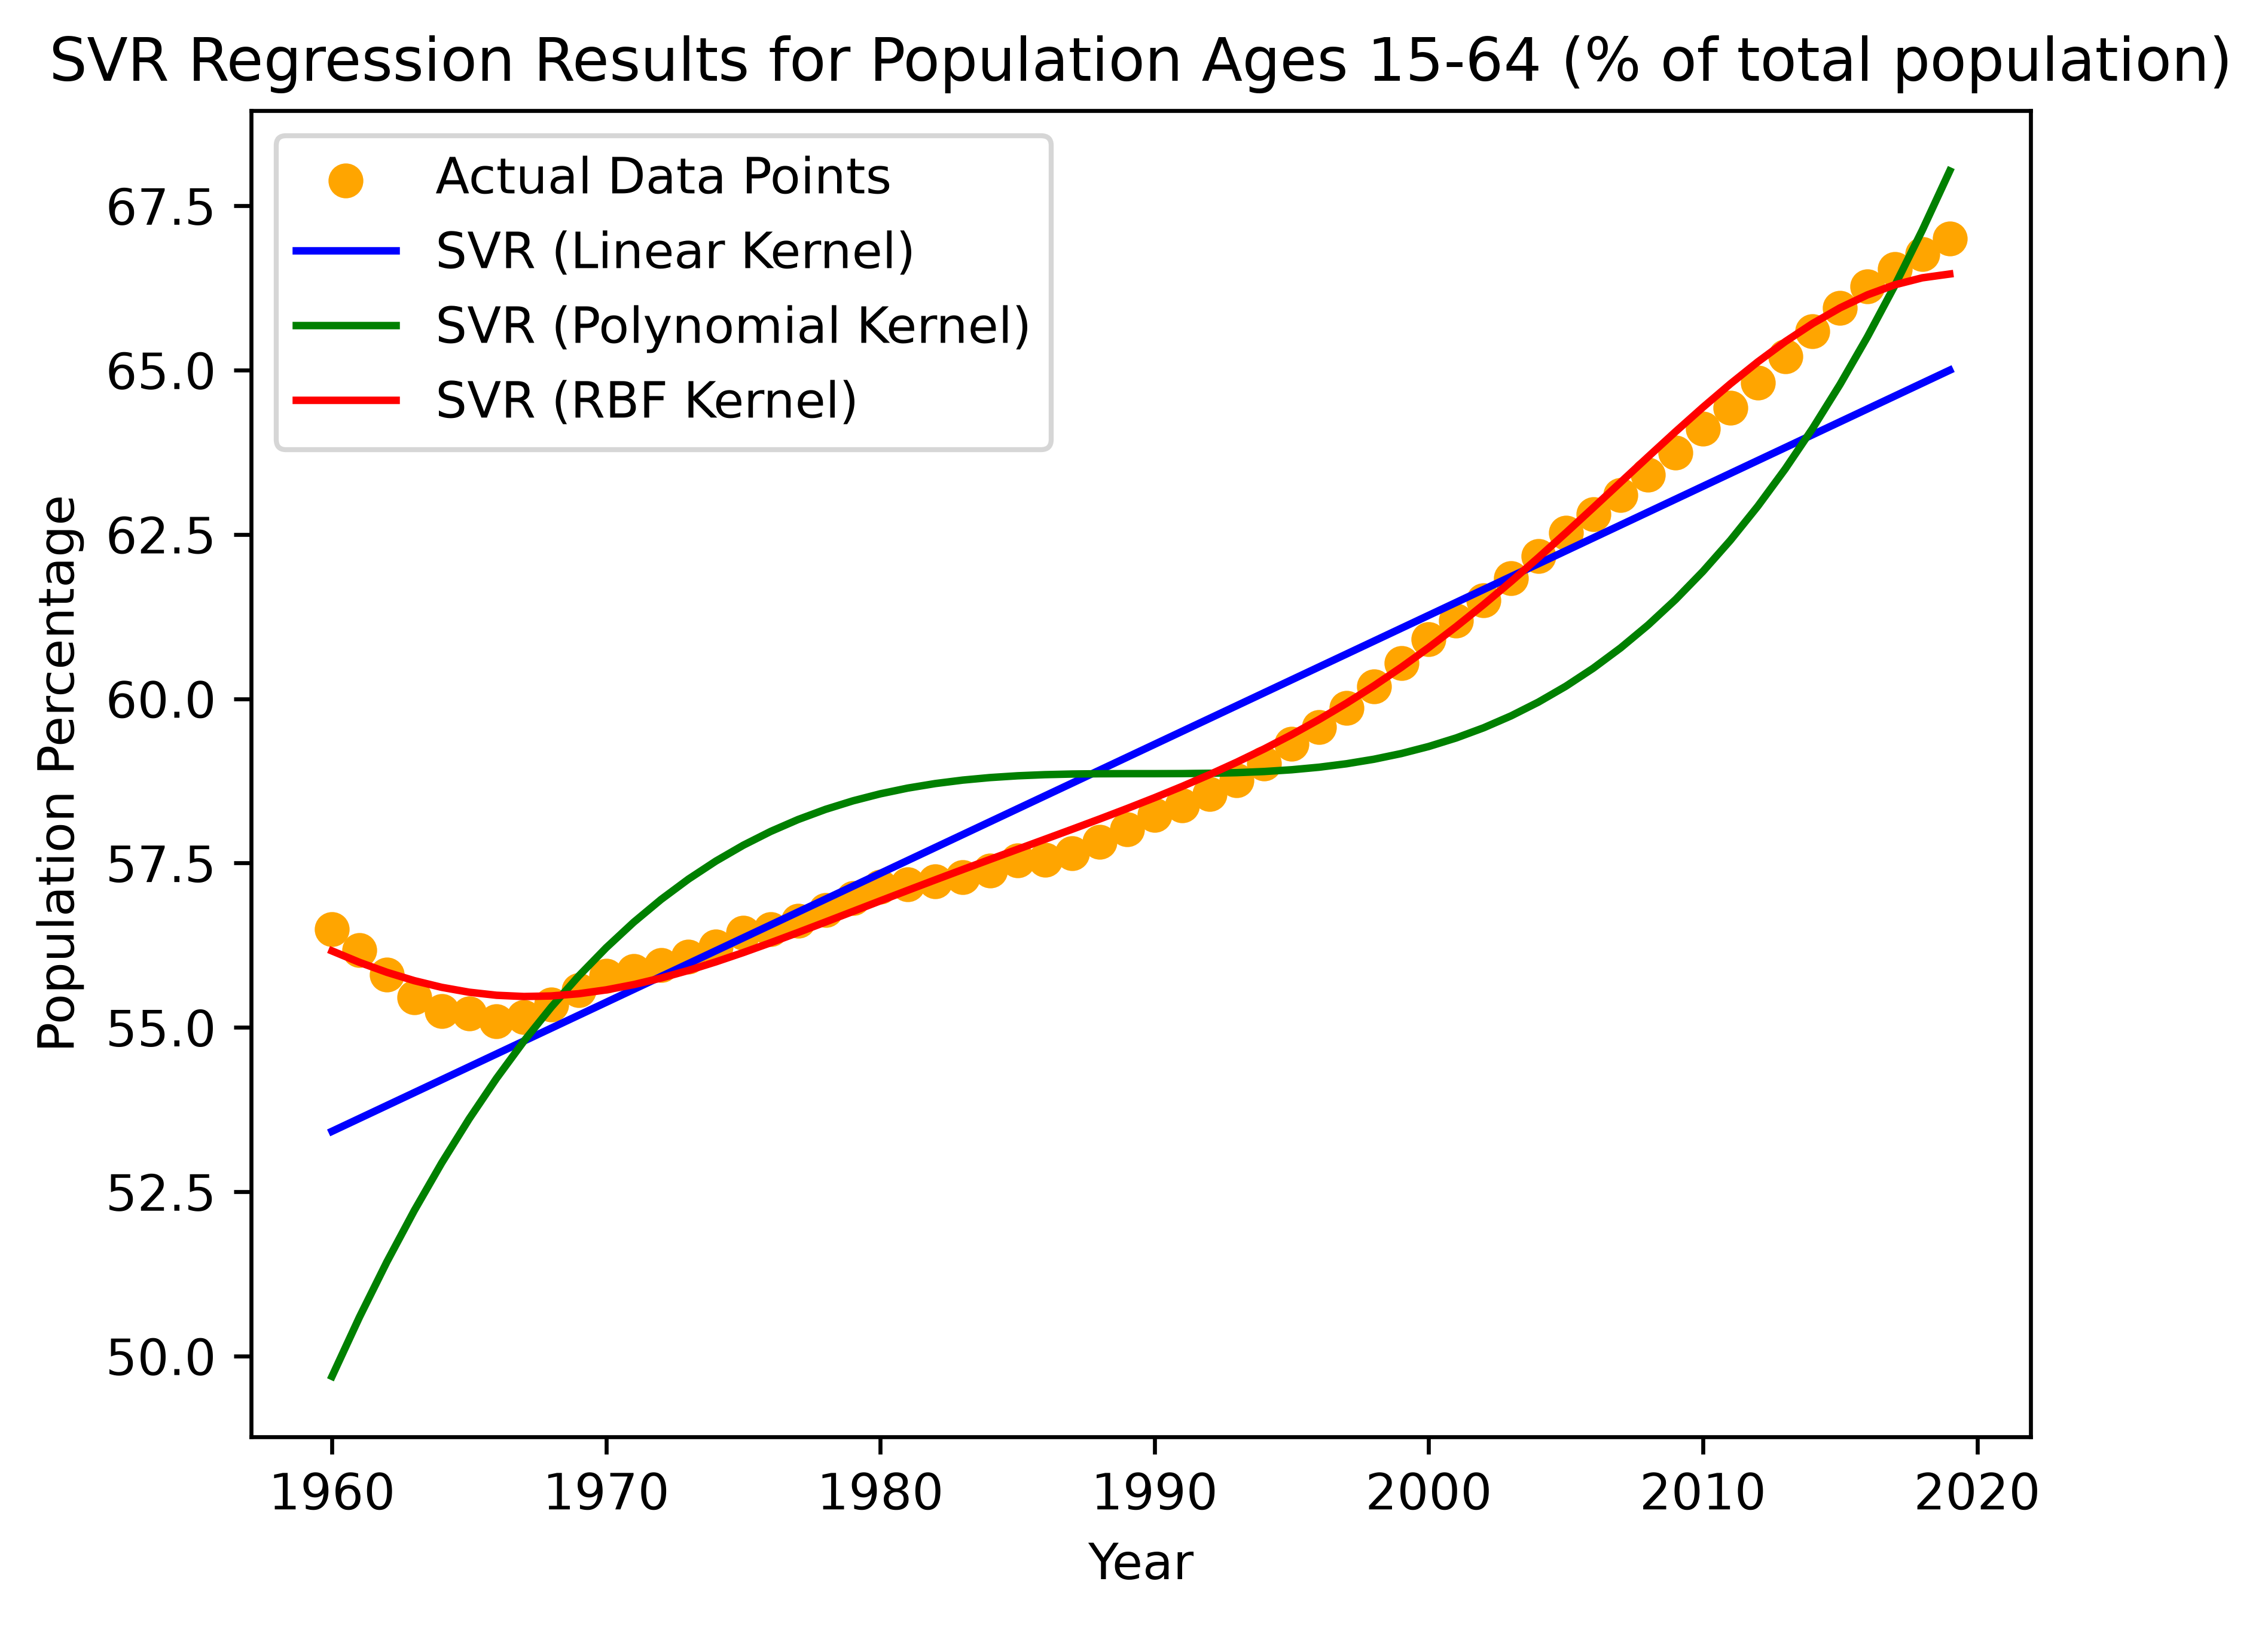

In [30]:
plt.figure(dpi=600)
plt.scatter(X, y, color='orange', label='Actual Data Points')
plt.plot(X, sc_y.inverse_transform(model_linear.predict(X_scaled).reshape(-1, 1)), color='blue', label='SVR (Linear Kernel)')
plt.plot(X, sc_y.inverse_transform(model_poly.predict(X_scaled).reshape(-1, 1)), color='green', label='SVR (Polynomial Kernel)')
plt.plot(X, sc_y.inverse_transform(model_rbf.predict(X_scaled).reshape(-1, 1)), color='red', label='SVR (RBF Kernel)')

plt.title('SVR Regression Results for Population Ages 15-64 (% of total population)')
plt.xlabel('Year')
plt.ylabel('Population Percentage')
plt.legend()
plt.show()

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data).
Remember: You must transform the input before predicting, and inverse transform the output.

In [24]:
year = 2025
year_scaled = sc_X.transform([[year]])
ans = model_rbf.predict(year_scaled).reshape(-1,1)
print(f"The predicted value input {year} is: {sc_y.inverse_transform(ans)[0][0]}")

The predicted value for input 2025 is: 65.82072271235397
